In [1]:
import os
DATA_DIR = r'food-101/images/'
print(os.listdir(DATA_DIR))
print(os.listdir(DATA_DIR)[:10])

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_sou

In [2]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn as nn
%matplotlib inline
from torchvision.utils import save_image
from tqdm.notebook import tqdm
import torch.nn.functional as F
from IPython.display import Image

In [3]:
image_size = 64
batch_size = 128
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
train_ds = ImageFolder(DATA_DIR, transform=T.Compose([
T.Resize(image_size),
T.CenterCrop(image_size),
T.ToTensor(),
T.Normalize(*stats)]))
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=3, pin_memory=True)

In [4]:
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

In [5]:
def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow=8).permute(1, 2, 0))

In [6]:
def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

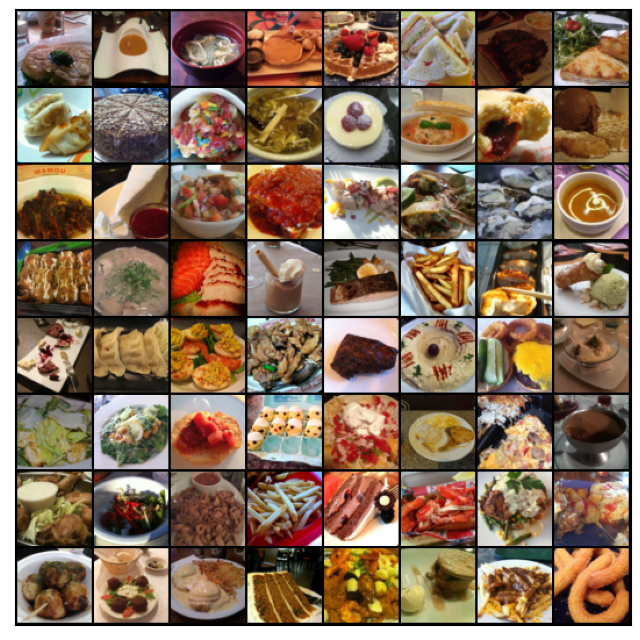

In [7]:
show_batch(train_dl)

In [8]:
def get_default_device():
    #“””Pick GPU if available, else CPU”””
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
def to_device(data, device):
#“””Move tensor(s) to chosen device”””
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)
class DeviceDataLoader():
#“””Wrap a dataloader to move data to a device”””
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    def __iter__(self):
    #“””Yield a batch of data after moving it to device”””
        for b in self.dl:
            yield to_device(b, self.device)
    def __len__(self):
    #“””Number of batches”””
        return len(self.dl)
#Based on where you’re running this notebook, your default device could be a CPU (torch.device('cpu')) or a GPU (torch.device('cuda'))
device = get_default_device()
train_dl = DeviceDataLoader(train_dl, device)

In [9]:
device = "cuda"

In [10]:
upper_size = 1536
discriminator = nn.Sequential(
# in: 3 x 64 x 64
nn.Conv2d(3, image_size, kernel_size=4, stride=2, padding=1, bias=False),
nn.BatchNorm2d(image_size),
nn.LeakyReLU(0.2, inplace=True),
# out: 64 x 32 x 32
nn.Conv2d(image_size, int(upper_size/4), kernel_size=4, stride=2, padding=1, bias=False),
nn.BatchNorm2d(int(upper_size/4)),
nn.LeakyReLU(0.2, inplace=True),
# out: 128 x 16 x 16
nn.Conv2d(int(upper_size/4), int(upper_size/2), kernel_size=4, stride=2, padding=1, bias=False),
nn.BatchNorm2d(int(upper_size/2)),
nn.LeakyReLU(0.2, inplace=True),
# out: 256 x 8 x 8
nn.Conv2d(int(upper_size/2), upper_size, kernel_size=4, stride=2, padding=1, bias=False),
nn.BatchNorm2d(upper_size),
nn.LeakyReLU(0.2, inplace=True),
# out: 512 x 4 x 4
nn.Conv2d(upper_size, 1, kernel_size=4, stride=1, padding=0, bias=False),
# out: 1 x 1 x 1
nn.Flatten(),
nn.Sigmoid())

In [11]:
print(device)

cuda


In [12]:
#discriminator = discriminator.load_state_dict(torch.load("D.pth"))
discriminator = to_device(discriminator, device)

In [13]:
latent_size = 128

generator = nn.Sequential(
# in: latent_size x 1 x 1
nn.ConvTranspose2d(latent_size, upper_size, kernel_size=4, stride=1, padding=0, bias=False),
nn.BatchNorm2d(upper_size),
nn.ReLU(True),
# out: 512 x 4 x 4
nn.ConvTranspose2d(upper_size, int(upper_size/2), kernel_size=4, stride=2, padding=1, bias=False),
nn.BatchNorm2d(int(upper_size/2)),
nn.ReLU(True),
# out: 256 x 8 x 8
nn.ConvTranspose2d(int(upper_size/2), int(upper_size/4), kernel_size=4, stride=2, padding=1, bias=False),
nn.BatchNorm2d(int(upper_size/4)),
nn.ReLU(True),
# out: 128 x 16 x 16
nn.ConvTranspose2d(int(upper_size/4), image_size, kernel_size=4, stride=2, padding=1, bias=False),
nn.BatchNorm2d(image_size),
nn.ReLU(True),
# out: 64 x 32 x 32

nn.ConvTranspose2d(image_size, 3, kernel_size=4, stride=2, padding=1, bias=False),
nn.Tanh()
# out: 3 x 64 x 64
)

In [14]:
#generator = generator.load_state_dict(torch.load("G.pth"))
generator = to_device(generator, device)

In [15]:
generator = to_device(generator, device)

In [16]:
def train_discriminator(real_images, opt_d):
    # Clear discriminator gradients
    opt_d.zero_grad()
    # Pass real images through discriminator
    real_preds = discriminator(real_images)
    real_targets = torch.ones(real_images.size(0), 1, device=device)
    real_loss = F.binary_cross_entropy(real_preds, real_targets)
    real_score = torch.mean(real_preds).item()
    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = generator(latent)
    # Pass fake images through discriminator
    fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
    fake_preds = discriminator(fake_images)
    fake_loss = F.binary_cross_entropy(fake_preds, fake_targets)
    fake_score = torch.mean(fake_preds).item()
    # Update discriminator weights
    loss = real_loss + fake_loss
    loss.backward()
    opt_d.step()
    return loss.item(), real_score, fake_score

In [17]:
def train_generator(opt_g):
    # Clear generator gradients
    opt_g.zero_grad()
    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = generator(latent)
    # Try to fool the discriminator
    preds = discriminator(fake_images)
    targets = torch.ones(batch_size, 1, device=device)
    loss = F.binary_cross_entropy(preds, targets)
    # Update generator weights
    loss.backward()
    opt_g.step()
    return loss.item()

In [18]:
sample_dir = 'generated'
os.makedirs(sample_dir, exist_ok=True)

In [25]:
def save_samples(index, latent_tensors, show=True):
    fake_images = generator(latent_tensors)
    fake_fname = 'generated-images-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=8)
    #print('Saving', fake_fname)
    if show:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(fake_images.cpu().detach(), nrow=8).permute(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


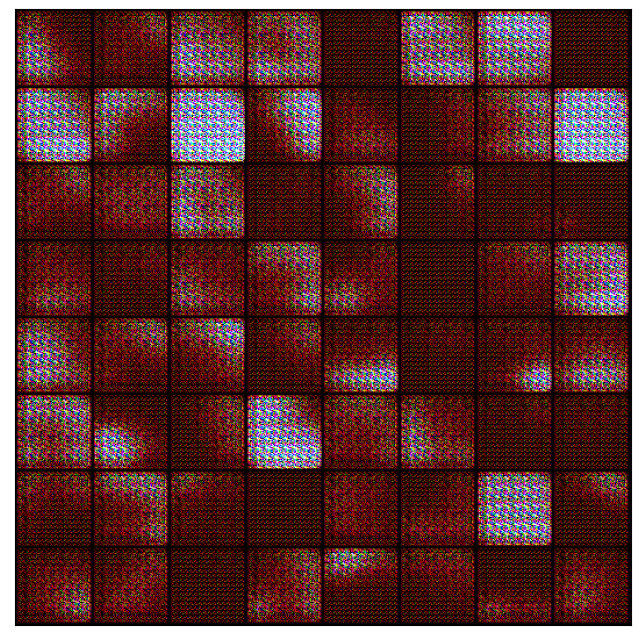

In [26]:
fixed_latent = torch.randn(64, latent_size, 1, 1, device=device)
save_samples(0, fixed_latent)

In [27]:
def fit(epochs, lr, start_idx=1):
    torch.cuda.empty_cache()
    # Losses & scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []
    # Create optimizers
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    for epoch in range(epochs):
        for real_images, _ in tqdm(train_dl):
            # Train discriminator
            loss_d, real_score, fake_score = train_discriminator(real_images, opt_d)
            # Train generator
            loss_g = train_generator(opt_g)
            # Record losses & scores
            losses_g.append(loss_g)
            losses_d.append(loss_d)
            real_scores.append(real_score)
            fake_scores.append(fake_score)
            # Log losses & scores (last batch)
            
            # Save generated images
            save_samples(epoch+start_idx, fixed_latent, show=False)
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs, loss_g, loss_d, real_score, fake_score))
    return losses_g, losses_d, real_scores, fake_scores

In [28]:
lr = 0.0002
epochs = 40
history = fit(epochs, lr)

  0%|          | 0/790 [00:00<?, ?it/s]

Epoch [1/40], loss_g: 4.5778, loss_d: 0.4265, real_score: 0.8535, fake_score: 0.1977


  0%|          | 0/790 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [46]:

torch.save(generator, 'G.pth')
torch.save(discriminator, 'D.pth')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Saving generated-images-0000.png
1


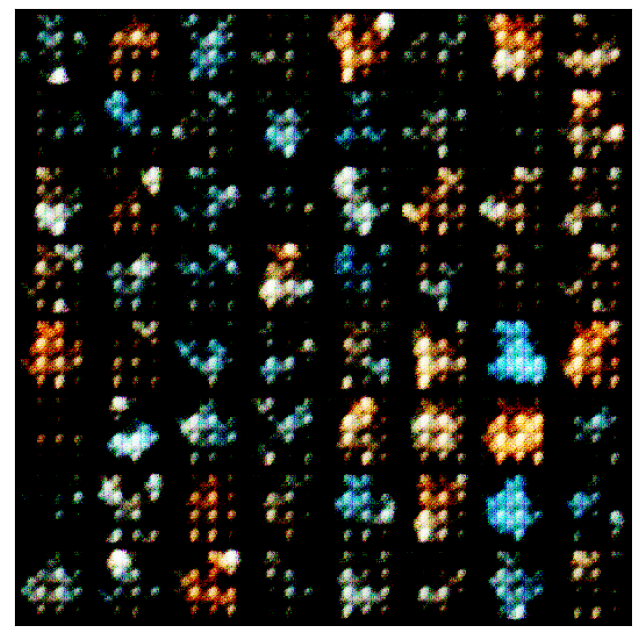

In [23]:
fixed_latent = torch.randn(64, latent_size, 1, 1, device=device)
save_samples(0, fixed_latent)
print(1)